In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Подгрузим данные

In [ ]:
patients_data1 = pd.read_csv(
    filepath_or_buffer="/content/drive/MyDrive/Colab Notebooks/Hackathon/mock-med-data/patients_data1.csv"
)
patients_data2 = pd.read_csv(
    filepath_or_buffer="/content/drive/MyDrive/Colab Notebooks/Hackathon/mock-med-data/patients_data2.csv"
)

patients_data = pd.concat([patients_data1, patients_data2], ignore_index=False)
patients_data.head(4)

,id,дата_рождения,пол,снилс,id_пациента,район_проживания,регион
0,cf72da6f-7733-4ffa-9849-61391f953e88,26.03.1939,М,092-095-623 75,NaN,NaN,NaN
1,d4a98607-5ef7-4d11-959a-3a33cc0a426f,18.10.1941,Ж,015-832-735 45,NaN,NaN,NaN
2,d015aa9d-dca5-4e83-96f6-d66259f66279,25.02.1949,Ж,024-836-532 53,NaN,NaN,NaN
3,3c081b4b-32a8-4cd1-b7f0-016624cb6a70,13.03.1941,М,013-290-556 16,NaN,NaN,NaN


## Наличие Nan

In [ ]:
print(patients_data.isna().sum())
print("\n")

print(f"{(patients_data.isna().sum() / len(patients_data)) * 100} %(percentage of nan's)", "\n")

id                   413799
дата_рождения             1
пол                       1
снилс                413799
id_пациента         2023361
район_проживания    2023361
регион              2023361
dtype: int64


id                  16.978738
дата_рождения        0.000041
пол                  0.000041
снилс               16.978738
id_пациента         83.021262
район_проживания    83.021262
регион              83.021262
dtype: float64 %(percentage of nan's) 



### Информация по типам

In [ ]:
patients_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2437160 entries, 0 to 413798
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                object 
 1   дата_рождения     object 
 2   пол               object 
 3   снилс             object 
 4   id_пациента       float64
 5   район_проживания  object 
 6   регион            object 
dtypes: float64(1), object(6)
memory usage: 148.8+ MB


In [28]:
patients_data.describe(include="O")

,id,дата_рождения,пол,снилс,район_проживания,регион
count,2023361,2437159,2437159,2023361,413799,413799
unique,2018413,38975,2,1754255,28,2
top,109e44c2-8e37-4114-8c7a-2352a3490df7,01.01.1947,Ж,000-000-000 00,ПРИМОРСКИЙ,Санкт-Петербург
freq,7,558,1369365,97455,40995,366812


In [29]:
patients_data.describe(exclude="O")

,id_пациента
count,4.137990e+05
mean,1.014073e+06
std,5.840888e+05
min,2.000000e+00
25%,5.075245e+05
50%,1.016432e+06
75%,1.519928e+06
max,2.023358e+06


## Форма датасета

In [ ]:
patients_data.shape

(2437160, 7)

## Количество уникальных лэйблов

In [ ]:
for col in patients_data.columns:
    print(f"{col} : ", {len(pd.unique(patients_data[col])): pd.unique(patients_data[col])[:10]}, "\n")

id :  {2018414: array(['cf72da6f-7733-4ffa-9849-61391f953e88',
       'd4a98607-5ef7-4d11-959a-3a33cc0a426f',
       'd015aa9d-dca5-4e83-96f6-d66259f66279',
       '3c081b4b-32a8-4cd1-b7f0-016624cb6a70',
       '10f314ea-c091-4e49-b4d9-55021e34e58b',
       '18bde2c4-1828-489b-a696-7af120c79bd6',
       '974d38e5-5bf7-4e50-9929-e1b8a6e0065e',
       'a1ac94bf-1a7e-403e-aa95-bfcfdda553c2',
       'e4c5c3f6-be49-4eee-a841-0f6449eba7c0',
       '854d5eea-1892-403d-8392-d67ed241ce00'], dtype=object)} 

дата_рождения :  {38976: array(['26.03.1939', '18.10.1941', '25.02.1949', '13.03.1941',
       '05.11.1930', '19.12.1979', '20.06.1948', '10.06.1937',
       '22.07.1941', '01.01.1941'], dtype=object)} 

пол :  {3: array(['М', 'Ж', nan], dtype=object)} 

снилс :  {1754256: array(['092-095-623 75', '015-832-735 45', '024-836-532 53',
       '013-290-556 16', '031-975-678 79', '057-418-493 82',
       '011-622-819 03', '119-462-433 62', '085-456-009 80',
       '085-742-867 10'], dtype=object)

## Рассмотрим распределение региона, района проживания, пол

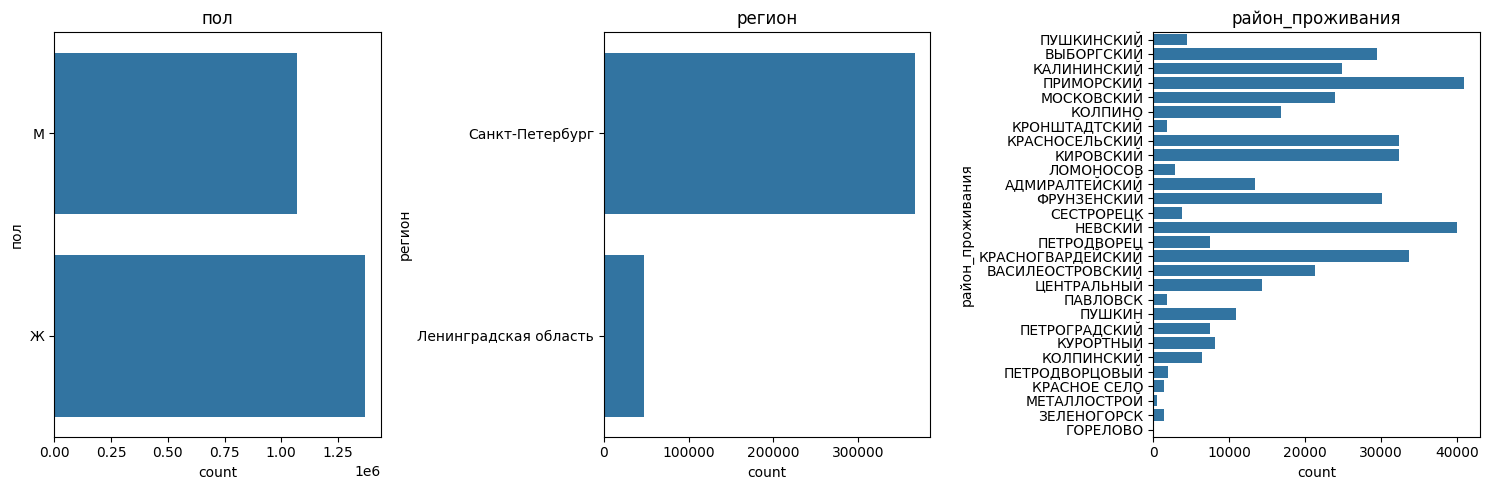

In [ ]:
cols = ["пол", "регион", "район_проживания"]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, col in enumerate(cols):
    sns.countplot(data=patients_data[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
for idx, col in enumerate(patients_data.columns):
    print(patients_data.iloc[:, idx].value_counts(ascending=False), "\n")

id
109e44c2-8e37-4114-8c7a-2352a3490df7    7
f605eaf8-3611-43cb-8980-022671f2026f    7
a60367ec-5a8e-4b3f-a3f2-554e9f812190    6
992aa2c2-9d00-4774-a1fc-02a6c30dc4d1    6
29159334-95a3-4a6f-a5fe-0bc1da6026a4    6
                                       ..
dbc1c057-8d44-43c5-99fc-4a6793caa483    1
313439a7-4825-4e82-b8bf-ec2214ff452e    1
90681ddb-f4dc-41dd-be38-e77f2da461ae    1
ffeb3e51-bd63-4fec-9266-bee3617cd2a5    1
509ff0ba-8030-459d-8ef5-c0d125bd30da    1
Name: count, Length: 2018413, dtype: int64 

дата_рождения
01.01.1947    558
01.01.1949    532
01.01.1948    405
01.01.1951    401
01.01.1950    378
             ... 
22.07.1913      1
08.03.1920      1
09.06.1920      1
16.06.1919      1
05.12.1919      1
Name: count, Length: 38975, dtype: int64 

пол
Ж    1369365
М    1067794
Name: count, dtype: int64 

снилс
000-000-000 00    97455
000-000-000 03    15340
000-000-000 01      844
114-466-829 59        7
121-597-548 65        6
                  ...  
025-220-485 05        1
201

## Выводы:
  - Есть сильный дисбаланс между `пол` в данных
  - 2_437_160 строк, 7 столбцов
  - Невероятное количиство пропусков под 83 % в `район проживания`, `регион`, `id_пациента` - просто перепометить как неизвестные, чтобы LLM не пыталась додумать
  - `id`, `снилс` - 16% особо роли не сыграет(скорее всего) можно допроверить совпадение строк по пропускам
  - `дата рождения` низкий процент пропуска - можно разбить на 'день,месяц, год' и далее анализировать его и вывести признак возраст